<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT1610: Cálculo I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 05: Razón de Cambio y Aproximaciones</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> Equipo Docente | <b>Fecha:</b> Septiembre, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" alt="Logo UC" style="height: 60px; width: auto;">
    </div>
</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">Contexto y Referencias</h3>
    <p>En ingeniería, la derivada es la herramienta fundamental para medir <b>razones de cambio</b> relevantes en muchas aplicaciones de ingenieria. En este laboratorio exploraremos la transición desde cambios promedio en un intervalo, hasta cambios instantáneos, y descubriremos cómo la linealización y los diferenciales nos ayudan a propagar errores de medición y simplificar modelos no lineales complejos. Basado en los <b>Capítulos 2 y 3</b> del libro <i>Cálculo de una variable: Trascendentes Tempranas (James Stewart)</i>. </p>
</div>

<div style="display: flex; gap: 20px;">
    <div style="flex: 1; border: 1px solid #27ae60; border-left: 8px solid #27ae60; padding: 15px; border-radius: 5px;">
        <h3 style="color: #27ae60; margin-top: 0;">Contenidos</h3>
        <ol>
            <li>Medidas de cambio en un intervalo y en un punto.</li>
            <li>Linealización (Aproximación Lineal de modelos).</li>
            <li>Razones de cambio y diferenciales (Propagación de errores).</li>
        </ol>
    </div>
    <div style="flex: 1; border: 1px solid #f39c12; border-left: 8px solid #f39c12; padding: 15px; border-radius: 5px;">
        <h3 style="color: #f39c12; margin-top: 0;">Objetivos de Aprendizaje</h3>
        <ul>
            <li>Estimar numéricamente tasas promedio utilizando estructuras tabulares en <code>Pandas</code>.</li>
            <li>Visualizar dinámicamente cómo las rectas secantes convergen a la recta tangente utilizando <code>Matplotlib</code>.</li>
            <li>Construir modelos de linealización para aproximar funciones trascendentes con polinomios de primer grado.</li>
            <li>Utilizar diferenciales en <code>SymPy</code> para estimar tolerancias y propagación de errores en diseño.</li>
        </ul>
    </div>
</div>


In [2]:
# Importar librerías de la sesión
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Configuración para visualización matemática
sp.init_printing()
%matplotlib inline

# Configuración de estilo
try: plt.style.use('seaborn-v0_8-whitegrid')
except: plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


# **1. Medidas de cambio en un intervalo y en un punto**

En física e ingeniería, la **razón de cambio promedio** de una variable $y$ con respecto a $x$ sobre un intervalo $[x_1, x_2]$ se define como:
$$\frac{\Delta y}{\Delta x} = \frac{f(x_2) - f(x_1)}{x_2 - x_1}$$

Si hacemos que el intervalo $\Delta x$ se reduzca hacia cero (es decir, $x_2 \to x_1$), el límite de esta razón promedio nos da la **razón de cambio instantánea** en el punto $x_1$, que es la definición de la derivada $f'(x_1)$.


### Ejemplo 1.1: Velocidad Promedio vs. Instantánea (Numérico)
La posición de un objeto en caída libre es $s(t) = 4.9t^2$. Calcularemos la velocidad promedio en intervalos cada vez más pequeños a partir de $t=2$ segundos para estimar la velocidad instantánea.


In [3]:
# Ejemplo 1.1: Aproximación tabular de la razón de cambio
def s(t):
    return 4.9 * t**2

t1 = 2.0
delta_t_vals = np.array([1.0, 0.5, 0.1, 0.01, 0.001, 0.0001])

# Cálculo vectorial de la razón de cambio promedio: (s(t2) - s(t1)) / delta_t
vel_promedio = (s(t1 + delta_t_vals) - s(t1)) / delta_t_vals

df_vel = pd.DataFrame({
    'Intervalo $\Delta t$': delta_t_vals,
    'Tiempo Final $t_2$': t1 + delta_t_vals,
    'Razón Promedio $\Delta s / \Delta t$': vel_promedio
})
display(df_vel)
print("Observe cómo la tasa promedio converge claramente a 19.6 m/s.")


,Intervalo $\Delta t$,Tiempo Final $t_2$,Razón Promedio $\Delta s / \Delta t$
0,1.0000,3.0000,24.50000
1,0.5000,2.5000,22.05000
2,0.1000,2.1000,20.09000
3,0.0100,2.0100,19.64900
4,0.0010,2.0010,19.60490
5,0.0001,2.0001,19.60049


Observe cómo la tasa promedio converge claramente a 19.6 m/s.


### Ejemplo 1.2: Cálculo Simbólico Exacto
Utilizaremos `SymPy` para calcular la derivada exacta de la función de posición anterior y evaluarla en $t=2$ para confirmar nuestra sospecha numérica.


In [4]:
# Ejemplo 1.2: Razón de cambio instantánea
t = sp.Symbol('t')
s_expr = 4.9 * t**2

# La velocidad instantánea es la derivada de la posición
v_expr = sp.diff(s_expr, t)
v_instantanea = v_expr.subs(t, 2)

print("Expresión de la posición s(t):", s_expr)
print("Expresión de la velocidad v(t):", v_expr)
print(f"\nVelocidad instantánea exacta en t=2: {v_instantanea} m/s")


Expresión de la posición s(t): 4.9*t**2
Expresión de la velocidad v(t): 9.8*t

Velocidad instantánea exacta en t=2: 19.6000000000000 m/s


### Ejemplo 1.3: Razón de Cambio Poblacional
Un cultivo de bacterias en un biorreactor crece según el modelo poblacional $P(t) = 500e^{0.4t}$ (donde $t$ está en horas). Calcularemos la tasa a la que están naciendo bacterias (razón de cambio instantánea) exactamente en la hora $t=5$.


In [5]:
# Ejemplo 1.3: Dinámica poblacional
t = sp.Symbol('t')
P = 500 * sp.exp(0.4 * t)

# Tasa de crecimiento (derivada)
dP_dt = sp.diff(P, t)

# Evaluamos en t = 5
tasa_en_5 = dP_dt.subs(t, 5)

print("Modelo poblacional P(t):", P)
print("Tasa de crecimiento dP/dt:", dP_dt)
print(f"\nEn la hora 5, la población está creciendo a una tasa de: {float(tasa_en_5):.2f} bacterias/hora")


Modelo poblacional P(t): 500*exp(0.4*t)
Tasa de crecimiento dP/dt: 200.0*exp(0.4*t)

En la hora 5, la población está creciendo a una tasa de: 1477.81 bacterias/hora


# **2. Linealización (Aproximación Lineal)**

Si hacemos un "zoom" muy profundo en la gráfica de una función diferenciable alrededor de un punto $a$, la curva es indistinguible de su recta tangente. Esta es la **Linealización** de $f$ en $a$:
$$L(x) = f(a) + f'(a)(x - a)$$

En ingeniería, sustituimos funciones trascendentes complejas por su aproximación lineal $L(x)$ para simplificar cálculos, asumiendo que operamos muy cerca del punto $a$.


### Ejemplo 2.1: Linealización de una Raíz
Aproximaremos el valor de $\sqrt{9.05}$ usando linealización. El punto "fácil" más cercano donde conocemos el valor exacto es $a = 9$.


In [33]:
# Ejemplo 2.1: Aproximación Lineal
x = sp.Symbol('x')
f = sp.sqrt(x)
a = 9

# 1. Componentes de la linealización
f_a = f.subs(x, a)
df_a = sp.diff(f, x).subs(x, a)

# 2. Función Linealizada L(x)
L = f_a + df_a * (x - a)

print(f"Linealización de sqrt(x) cerca de a=9: L(x) = {L}")

# 3. Aproximación vs Valor Real
x_val = 9.05
aprox = float(L.subs(x, x_val))
real = float(np.sqrt(x_val))

print(f"\nAproximación lineal de sqrt(9.05): {aprox}")
print(f"Valor real (computacional):       {real}")
print(f"Error absoluto:                   {abs(real - aprox):.6f}")


Linealización de sqrt(x) cerca de a=9: L(x) = x/6 + 3/2

Aproximación lineal de sqrt(9.05): 3.0083333333333333
Valor real (computacional):       3.0083217912982647
Error absoluto:                   0.000012


### Ejemplo 2.2: Visualizando el Error de Linealización
Graficaremos la función y su linealización para visualizar cómo el error aumenta rápidamente a medida que nos alejamos del punto $a=9$.


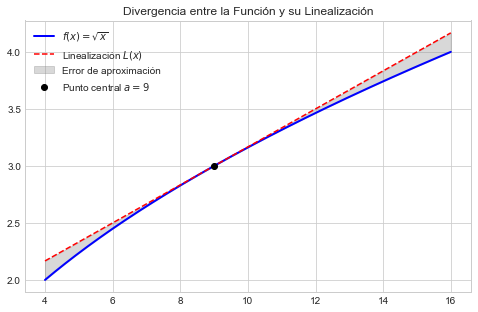

In [10]:
# Ejemplo 2.2: Gráfico de Linealización
x_vals = np.linspace(4, 16, 200)
f_num = np.sqrt(x_vals)

# L(x) = 3 + (1/6)*(x - 9)
L_num = float(f_a) + float(df_a)*(x_vals - a)

plt.plot(x_vals, f_num, label='$f(x) = \sqrt{x}$', color='blue', lw=2)
plt.plot(x_vals, L_num, label='Linealización $L(x)$', color='red', linestyle='--')

# Rellenar el área de error
plt.fill_between(x_vals, f_num, L_num, color='gray', alpha=0.3, label='Error de aproximación')

plt.scatter([9], [3], color='black', zorder=5, label='Punto central $a=9$')
plt.title("Divergencia entre la Función y su Linealización")
plt.legend()
plt.show()


### Ejemplo 2.3: La Aproximación de Ángulo Pequeño
En la dinámica de un péndulo, la ecuación diferencial contiene el término $\sin(\theta)$. Para oscilaciones pequeñas (cerca de $\theta = 0$), los ingenieros usan la linealización $\sin(\theta) \approx \theta$. Demostrémoslo analíticamente.


Función original: f(θ) = sin(theta)
Derivada evaluada en θ=0: f'(0) = 1
Linealización L(θ) = theta

¡Esta es la famosa aproximación de ángulo pequeño empleada en física!


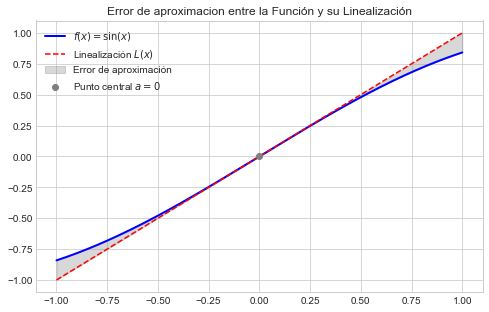

In [34]:
# Ejemplo 2.3: Linealización Trigonométrica
theta = sp.Symbol('theta')
f_trig = sp.sin(theta)
a_trig = 0

f_a_trig = f_trig.subs(theta, a_trig)
df_a_trig = sp.diff(f_trig, theta).subs(theta, a_trig)

L_trig = f_a_trig + df_a_trig * (theta - a_trig)

print(f"Función original: f(θ) = {f_trig}")
print(f"Derivada evaluada en θ=0: f'(0) = {df_a_trig}")
print(f"Linealización L(θ) = {L_trig}")
print("\n¡Esta es la famosa aproximación de ángulo pequeño empleada en física!")

x_vals = np.linspace(-1, 1, 200)
L_num = sp.lambdify(theta, L_trig, 'numpy')
f_num = sp.lambdify(theta, f_trig, 'numpy')

plt.plot(x_vals, f_num(x_vals), label='$f(x) = \sin(x)$', color='blue', lw=2)
plt.plot(x_vals, L_num(x_vals), label='Linealización $L(x)$', color='red', linestyle='--')

# Rellenar el área de error
plt.fill_between(x_vals, f_num(x_vals), L_num(x_vals), color='gray', alpha=0.3, label='Error de aproximación')

plt.scatter([0], [0], color='C07', zorder=5, label='Punto central $a=0$')
plt.title("Error de aproximacion entre la Función y su Linealización")
plt.legend()
plt.show()


# **3. Razones de Cambio y Diferenciales**

En la notación $\frac{dy}{dx}$, un **diferencial** considera a $dy$ y $dx$ como variables algebraicas independientes:
$$dy = f'(x) \, dx$$

En ingeniería y manufactura, **$dx$ representa el error absoluto de medición** en el instrumento, y **$dy$ es el error propagado** en el cálculo final. Los diferenciales nos permiten estimar esta propagación de manera rápida sin tener que recalcular toda la función.


### Ejemplo 3.1: Tolerancia de Fabricación
Un rodamiento esférico debe tener un radio de $r = 5$ cm. El calibre del torno tiene un margen de error de $dr = \pm 0.05$ cm. ¿Cuál es el error máximo propagado en el volumen de la esfera ($V = \frac{4}{3}\pi r^3$)?


In [35]:
# Ejemplo 3.1: Diferenciales en propagación de errores
r = sp.Symbol('r')
V = (4/3) * sp.pi * r**3

# Derivada dV/dr
dV_dr = sp.diff(V, r)

# Diferencial: dV = V'(r) * dr
r_val = 5
dr_val = 0.05
dV_val = float(dV_dr.subs(r, r_val)) * dr_val

volumen_ideal = float(V.subs(r, r_val))

print(f"El volumen ideal es: {volumen_ideal:.2f} cm³")
print(f"El error propagado estimado es: dV = ±{dV_val:.2f} cm³")
print(f"Error Relativo (dV/V): {(dV_val / volumen_ideal)*100:.2f}%")


El volumen ideal es: 523.60 cm³
El error propagado estimado es: dV = ±15.71 cm³
Error Relativo (dV/V): 3.00%


### Ejemplo 3.2: Expansión Térmica de una Placa
Una placa cuadrada de metal tiene un lado de $x = 10$ m. Debido al calor del día, el lado se dilata $dx = 0.02$ m. Usaremos diferenciales para estimar rápidamente cuánto aumentó el Área $A(x) = x^2$.


In [36]:
# Ejemplo 3.2: Diferencial de Área
x = sp.Symbol('x')
A = x**2

dA_dx = sp.diff(A, x)

x_val = 10
dx_val = 0.02

# dA = A'(x) * dx
dA_val = float(dA_dx.subs(x, x_val)) * dx_val

print(f"Modelo de Área A(x) = {A}")
print(f"El diferencial dA = {dA_dx} * dx")
print(f"\nAumento estimado de área por calor: dA = {dA_val} m²")


Modelo de Área A(x) = x**2
El diferencial dA = 2*x * dx

Aumento estimado de área por calor: dA = 0.4 m²


### Ejemplo 3.3: Error en Medición Trigonométrica
Un topógrafo calcula la altura de un edificio usando $h = 50 \tan(\theta)$. Mide el ángulo $\theta = \pi/4$ radianes (45°), pero su teodolito tiene un error de $d\theta = 0.01$ radianes. Estime el error en la altura.


In [37]:
# Ejemplo 3.3: Diferenciales con Trigonometría
theta = sp.Symbol('theta')
h = 50 * sp.tan(theta)

dh_dtheta = sp.diff(h, theta)

theta_val = sp.pi / 4
dtheta_val = 0.01

# dh = h'(theta) * dtheta
dh_val = float(dh_dtheta.subs(theta, theta_val)) * dtheta_val

print(f"Función de altura h(θ) = {h}")
print(f"Derivada dh/dθ = {dh_dtheta}")
print(f"\nError estimado en la medición del edificio: dh = ±{dh_val:.2f} metros")


Función de altura h(θ) = 50*tan(theta)
Derivada dh/dθ = 50*tan(theta)**2 + 50

Error estimado en la medición del edificio: dh = ±1.00 metros


<div class="alert alert-block alert-success" style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;"> 
    <h2 style="color: #2e7d32; margin-top: 0;">🏁 Ticket de Salida</h2>
    <p style="font-size: 1.1em; color: #1b5e20;"><strong>¡Felicidades!</strong> Ha completado la parte teórica del laboratorio. Ahora, demuestre su dominio de las herramientas de razón de cambio, linealización y diferenciales resolviendo los siguientes problemas propuestos en Python.</p>
    <h3 style="color: #2e7d32; margin-top: 15px;">💻 Ejercicios: </h3>
</div>


### Ejercicio 1: Razón de Reacción Química
La concentración de un producto químico en un biorreactor sigue el modelo $C(t) = \frac{10t}{t^2 + 4}$ (mol/L).
1. Construya una tabla en Pandas calculando la tasa promedio de reacción ($\frac{\Delta C}{\Delta t}$) a partir de $t_1 = 2$ con incrementos $\Delta t = [1.0, 0.5, 0.1, 0.01]$.
2. Use SymPy para calcular la tasa instantánea analítica en $t=2$ y verifique que el resultado tabular concuerde.
---


In [15]:
# Escriba su código computacional aquí


### Ejercicio 2: Secante Térmica y Enfriamiento
La temperatura de un componente electrónico tras apagarse se modela como $T(t) = 80e^{-0.3t} + 20$ grados Celsius.
1. Utilizando Matplotlib, grafique $T(t)$ para $t \in [0, 10]$.
2. Calcule la pendiente de la recta secante entre $t=1$ y $t=5$. Trace esta recta secante sobre su gráfico original con un color contrastante y etiqueta.
---


In [16]:
# Escriba su código computacional aquí


### Ejercicio 3: Linealización de Carga Eléctrica
La carga en un condensador está dada por $Q(V) = 5 \ln(V + 1)$. Se espera que el voltaje del circuito fluctúe levemente alrededor de $V = 3$ voltios.
1. Obtenga la linealización $L(V)$ de la carga centrada en $V=3$.
2. Estime el valor de la carga para un voltaje $V=3.1$ usando su linealización y compárelo (calcule el error) con el valor directo real.
---


In [17]:
# Escriba su código computacional aquí


### Ejercicio 4: Tolerancia en Discos Duros
Un plato de disco duro tiene forma de círculo. Su radio de diseño es $r = 4.5$ cm. El fabricante especifica que la tolerancia en la maquinaria de corte perimetral es de $dr = \pm 0.01$ cm.
1. Escriba la función del Área de un círculo en `SymPy`.
2. Utilice diferenciales para calcular el error máximo propagado en la superficie (Área) del disco.
3. Imprima el resultado especificando las unidades correctas.
---


In [18]:
# Escriba su código computacional aquí


<div style="width: 100%; border-top: 2px solid #ddd; padding-top: 15px; margin-top: 30px; font-family: sans-serif; font-size: 0.85em; color: #666;">
    <p>
        <strong>© 2026 Manuel A. Sánchez </strong><br>
        <a href="https://www.mat.uc.cl/" style="color: #003366; text-decoration: none;">Facultad de Matemáticas</a><br>
        Pontificia Universidad Católica de Chile
    </p>
    <p>
        <i>Este material está diseñado para el curso MAT1610 y no debe ser redistribuido sin permiso explícito.</i>
    </p>
</div>
